# 🏥 Hospital Readmission Prediction
## Phase 1: Exploratory Data Analysis (EDA)

**Dataset**: UCI Diabetes 130-US Hospitals (1999–2008)  
**Goal**: Understand the data, identify patterns, and build intuition before modeling.  
**Target Variable**: `readmitted` — whether a patient was readmitted within 30 days (`<30`), after 30 days (`>30`), or not at all (`NO`)

---
### Notebook Structure
1. Environment Setup & Data Loading
2. Initial Data Inspection
3. Target Variable Analysis
4. Missing Value Analysis
5. Demographic Analysis
6. Clinical Feature Analysis
7. Correlation & Multivariate Analysis
8. Key Insights Summary
---

In [1]:
## 1. Environment Setup & Data Loading
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Display Settings ────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# ── Plot Theme ──────────────────────────────────────────────────────────────
PALETTE = {
    'primary'  : '#2563EB',   # blue
    'danger'   : '#DC2626',   # red — readmitted <30
    'warning'  : '#D97706',   # amber — readmitted >30
    'success'  : '#16A34A',   # green — not readmitted
    'neutral'  : '#6B7280',   # gray
}
READMIT_COLORS = [PALETTE['danger'], PALETTE['warning'], PALETTE['success']]

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

print('✅ Libraries loaded successfully')
# ── Load Dataset ────────────────────────────────────────────────────────────
# Download from: https://www.kaggle.com/datasets/brandao/diabetes
# Place 'diabetic_data.csv' in the same folder as this notebook

df = pd.read_csv(r"C:\Users\omc\Documents\Excel works\projects\diabetic_data.csv")
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')


✅ Libraries loaded successfully
Dataset shape: 101,766 rows × 50 columns
Memory usage: 202.2 MB


In [3]:
## 2. Initial Data Inspection
# ── First Look ───────────────────────────────────────────────────────────────
df.head()
# ── Dtypes & Non-Null Counts ─────────────────────────────────────────────────
df.info()
# ── Descriptive Statistics (Numeric Columns) ─────────────────────────────────
df.describe()
# ── Descriptive Statistics (Categorical Columns) ─────────────────────────────
df.describe(include='object')
# ── Replace '?' placeholder with NaN (this dataset uses '?' for missing) ─────
df.replace('?', np.nan, inplace=True)

print('✅ Replaced ? with NaN')
print(f'Total missing values after replacement: {df.isnull().sum().sum():,}')
# ── Duplicate Check ───────────────────────────────────────────────────────────
# Note: A patient can have multiple encounters; encounter_id should be unique
print(f'Duplicate encounter_id rows : {df.duplicated(subset=["encounter_id"]).sum()}')
print(f'Unique patients             : {df["patient_nbr"].nunique():,}')
print(f'Unique encounters           : {df["encounter_id"].nunique():,}')

# Keep only the first encounter per patient to avoid data leakage
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f'\nAfter keeping first encounter per patient: {df.shape[0]:,} rows')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

Readmission distribution (raw):
  NO    → 42,985 (60.1%)
  >30   → 22,240 (31.1%)
  <30   →  6,293 (8.8%)


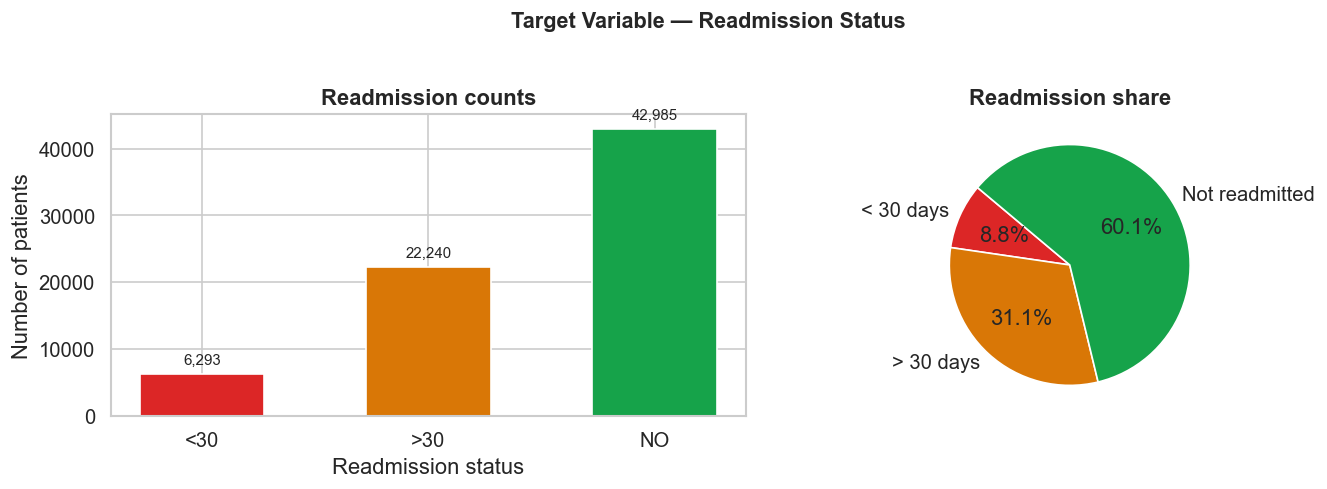


💡 Insight: Dataset is imbalanced — <30 day readmissions are the minority class.
   We will need SMOTE or class_weight adjustment in modeling phase.
30-day readmission rate: 8.8%
This is our binary target for all modeling steps.


In [4]:
## 3. Target Variable Analysis

''' We'll binarise the target: **readmitted within 30 days (`<30`) = 1**, everything else = 0.  
This is the clinically and financially critical threshold. '''
# ── Raw 3-class Distribution ──────────────────────────────────────────────────
target_counts = df['readmitted'].value_counts()
target_pct    = df['readmitted'].value_counts(normalize=True) * 100

print('Readmission distribution (raw):')
for label in ['NO', '>30', '<30']:
    print(f'  {label:5s} → {target_counts[label]:6,} ({target_pct[label]:.1f}%)')
# ── Plot: Raw Distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
order = ['<30', '>30', 'NO']
ax = axes[0]
bars = ax.bar(order, [target_counts[o] for o in order],
              color=READMIT_COLORS, edgecolor='white', width=0.55)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_title('Readmission counts', fontweight='bold')
ax.set_ylabel('Number of patients')
ax.set_xlabel('Readmission status')

# Pie chart
axes[1].pie([target_counts[o] for o in order],
            labels=['< 30 days', '> 30 days', 'Not readmitted'],
            colors=READMIT_COLORS, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Readmission share', fontweight='bold')

plt.suptitle('Target Variable — Readmission Status', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_target_distribution.png', bbox_inches='tight')
plt.show()
print('\n💡 Insight: Dataset is imbalanced — <30 day readmissions are the minority class.')
print('   We will need SMOTE or class_weight adjustment in modeling phase.')
# ── Binarise Target ───────────────────────────────────────────────────────────
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

readmit_rate = df['readmit_30'].mean() * 100
print(f'30-day readmission rate: {readmit_rate:.1f}%')
print(f'This is our binary target for all modeling steps.')


Columns with missing data: 9

           column  missing_count  missing_pct
           weight          68665        96.00
    max_glu_serum          68062        95.20
        A1Cresult          58532        81.80
medical_specialty          34477        48.20
       payer_code          31043        43.40
             race           1948         2.70
           diag_3           1225         1.70
           diag_2            294         0.40
           diag_1             11         0.00


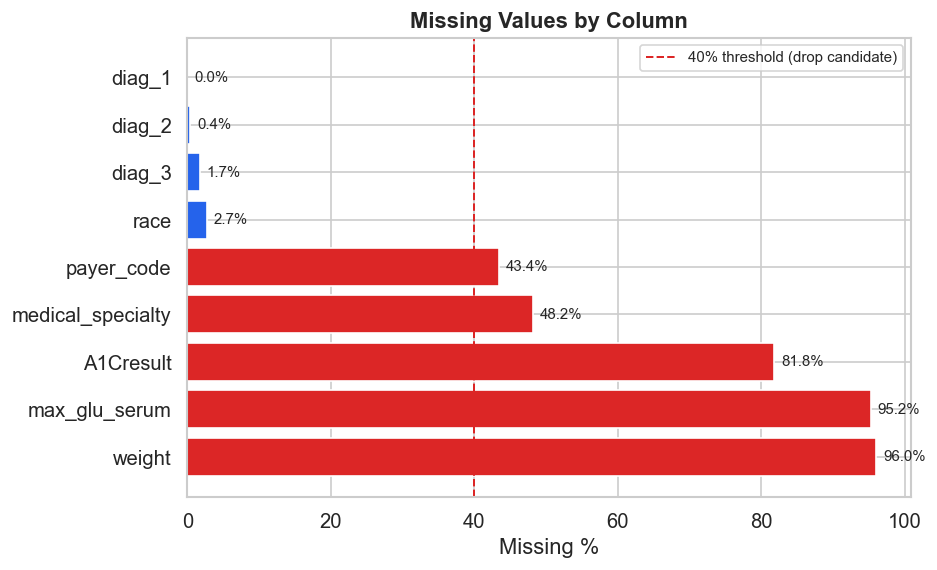


💡 Insight: Columns with >40% missing (e.g. weight, payer_code) will be dropped in Phase 2.


In [5]:
## 4. Missing Value Analysis
# ── Missing Value Summary ─────────────────────────────────────────────────────
missing = (
    df.isnull()
      .sum()
      .reset_index()
      .rename(columns={0: 'missing_count', 'index': 'column'})
)
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(1)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing data: {len(missing)}')
print()
print(missing.to_string(index=False))
# ── Plot: Missing Values ───────────────────────────────────────────────────────
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.55)))
    colors = ['#DC2626' if p > 40 else '#D97706' if p > 10 else '#2563EB'
              for p in missing['missing_pct']]
    bars = ax.barh(missing['column'], missing['missing_pct'], color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='{:.1f}%', padding=4, fontsize=9)
    ax.axvline(40, ls='--', color='#DC2626', lw=1.2, label='40% threshold (drop candidate)')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('02_missing_values.png', bbox_inches='tight')
    plt.show()
    print('\n💡 Insight: Columns with >40% missing (e.g. weight, payer_code) will be dropped in Phase 2.')
else:
    print('No missing values found (after ? replacement).')

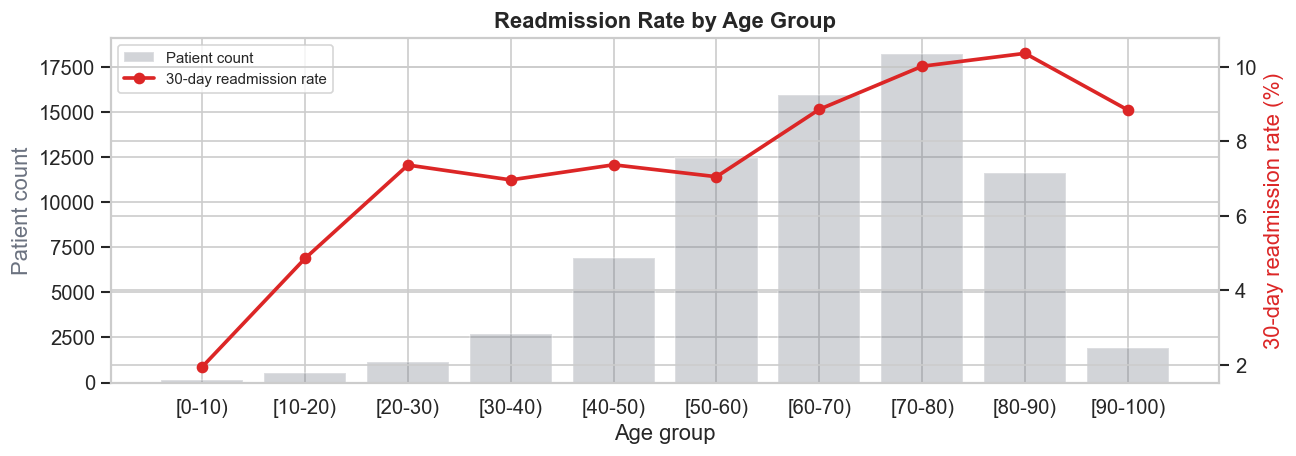

💡 Insight: Age group [80-90) has the highest 30-day readmission rate.
gender  count  mean_pct
Female  38025      8.86
  Male  33490      8.73

💡 Insight: Check if gender is a significant predictor (often it is not for readmission).


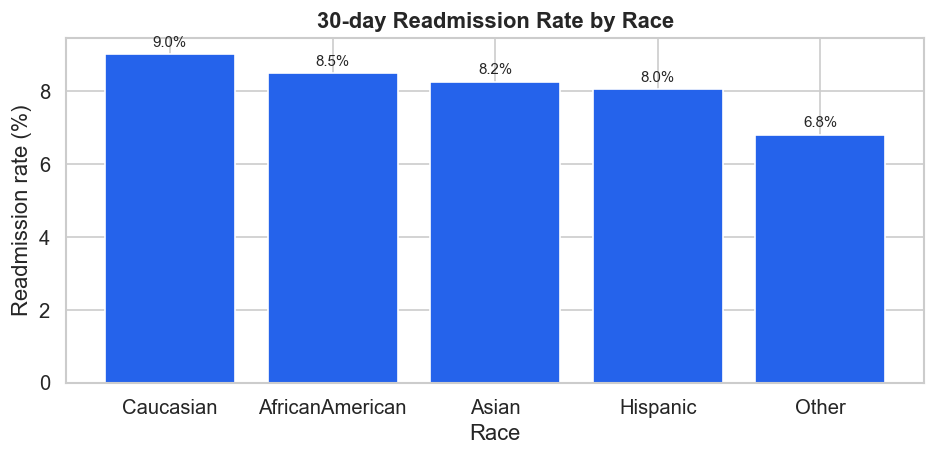

In [6]:
## 5. Demographic Analysis
# ── Age vs Readmission ────────────────────────────────────────────────────────
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

age_readmit = (
    df.groupby('age')['readmit_30']
      .agg(['mean', 'count'])
      .reindex(age_order)
      .reset_index()
)
age_readmit['mean_pct'] = age_readmit['mean'] * 100

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.bar(age_readmit['age'], age_readmit['count'],
        color=PALETTE['neutral'], alpha=0.3, label='Patient count')
ax2.plot(age_readmit['age'], age_readmit['mean_pct'],
         color=PALETTE['danger'], marker='o', linewidth=2.2, label='30-day readmission rate')

ax1.set_xlabel('Age group')
ax1.set_ylabel('Patient count', color=PALETTE['neutral'])
ax2.set_ylabel('30-day readmission rate (%)', color=PALETTE['danger'])
ax1.set_title('Readmission Rate by Age Group', fontweight='bold')
plt.xticks(rotation=30)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('03_age_readmission.png', bbox_inches='tight')
plt.show()

top_age = age_readmit.loc[age_readmit['mean_pct'].idxmax(), 'age']
print(f'💡 Insight: Age group {top_age} has the highest 30-day readmission rate.')
# ── Gender vs Readmission ─────────────────────────────────────────────────────
gender_readmit = (
    df[df['gender'].isin(['Male', 'Female'])]
      .groupby('gender')['readmit_30']
      .agg(['mean', 'count'])
      .reset_index()
)
gender_readmit['mean_pct'] = gender_readmit['mean'] * 100
print(gender_readmit[['gender', 'count', 'mean_pct']].to_string(index=False))
print('\n💡 Insight: Check if gender is a significant predictor (often it is not for readmission).')
# ── Race vs Readmission ───────────────────────────────────────────────────────
race_readmit = (
    df.dropna(subset=['race'])
      .groupby('race')['readmit_30']
      .agg(['mean', 'count'])
      .sort_values('mean', ascending=False)
      .reset_index()
)
race_readmit['mean_pct'] = race_readmit['mean'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(race_readmit['race'], race_readmit['mean_pct'],
              color=PALETTE['primary'], edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
ax.set_title('30-day Readmission Rate by Race', fontweight='bold')
ax.set_ylabel('Readmission rate (%)')
ax.set_xlabel('Race')
plt.tight_layout()
plt.savefig('04_race_readmission.png', bbox_inches='tight')
plt.show()

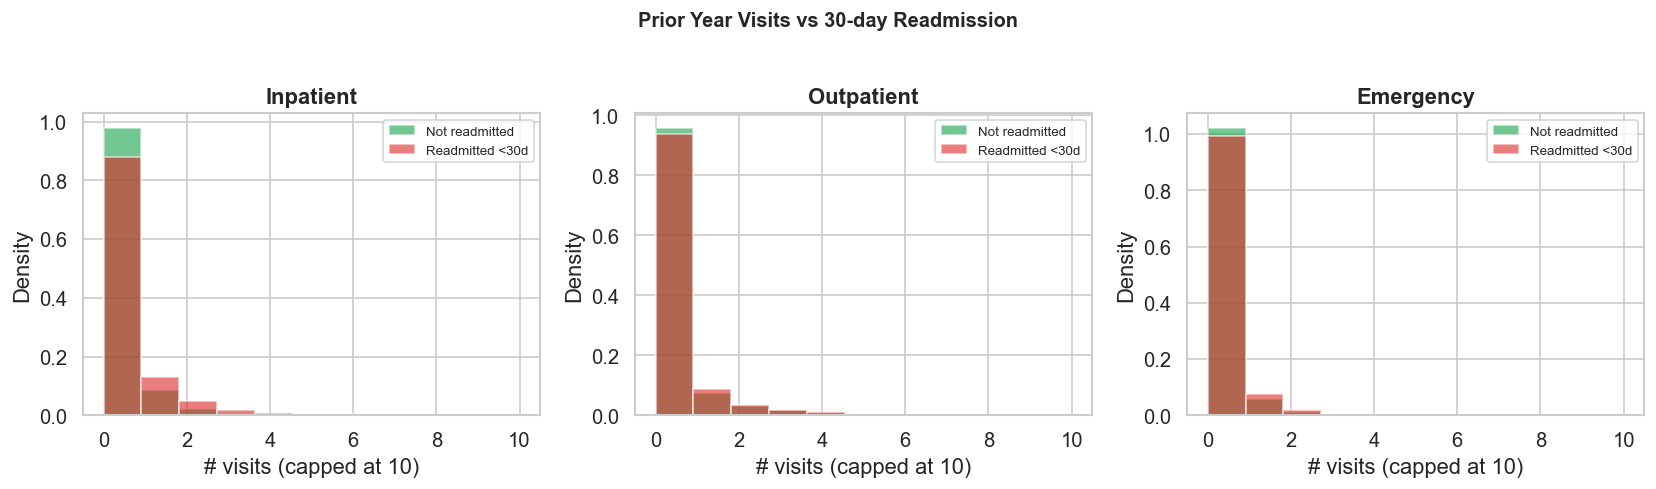

number_inpatient         : Not readmitted = 0.16 | Readmitted = 0.37
number_outpatient        : Not readmitted = 0.28 | Readmitted = 0.31
number_emergency         : Not readmitted = 0.10 | Readmitted = 0.15


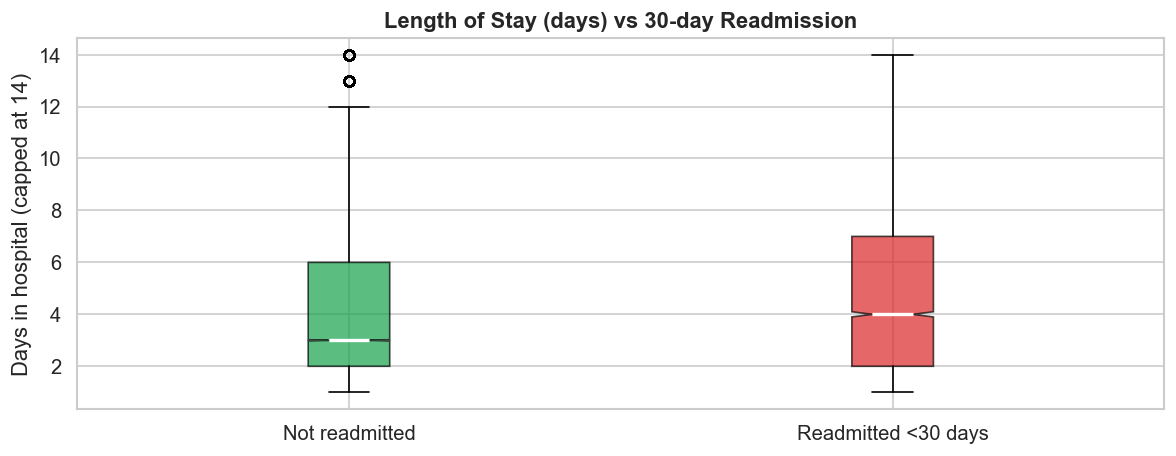

Avg LOS — Not readmitted: 4.2 days | Readmitted: 4.8 days


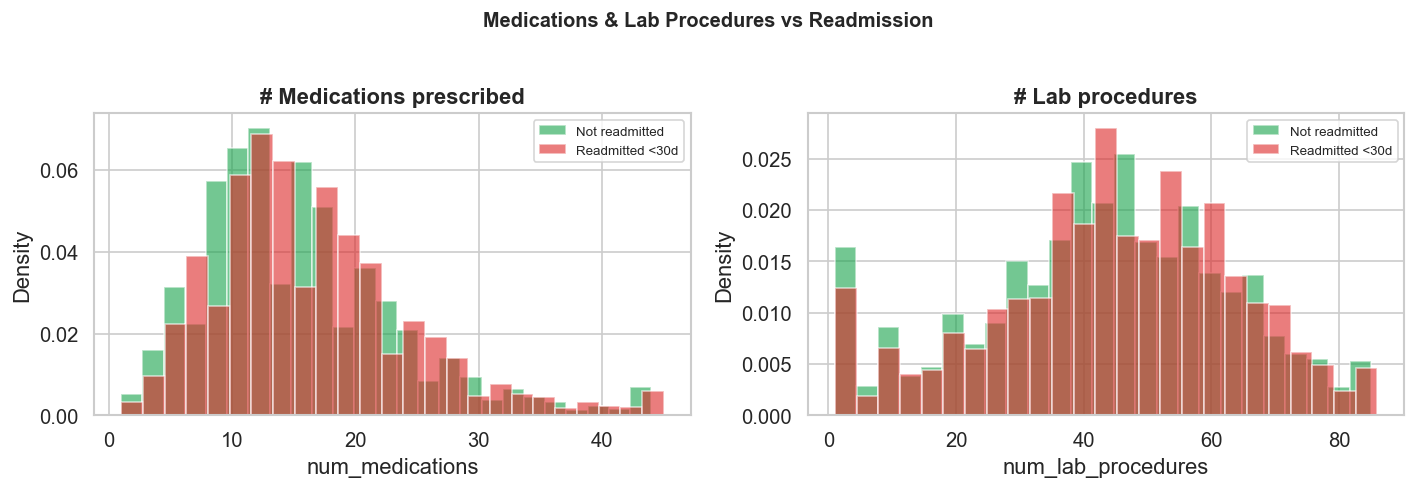

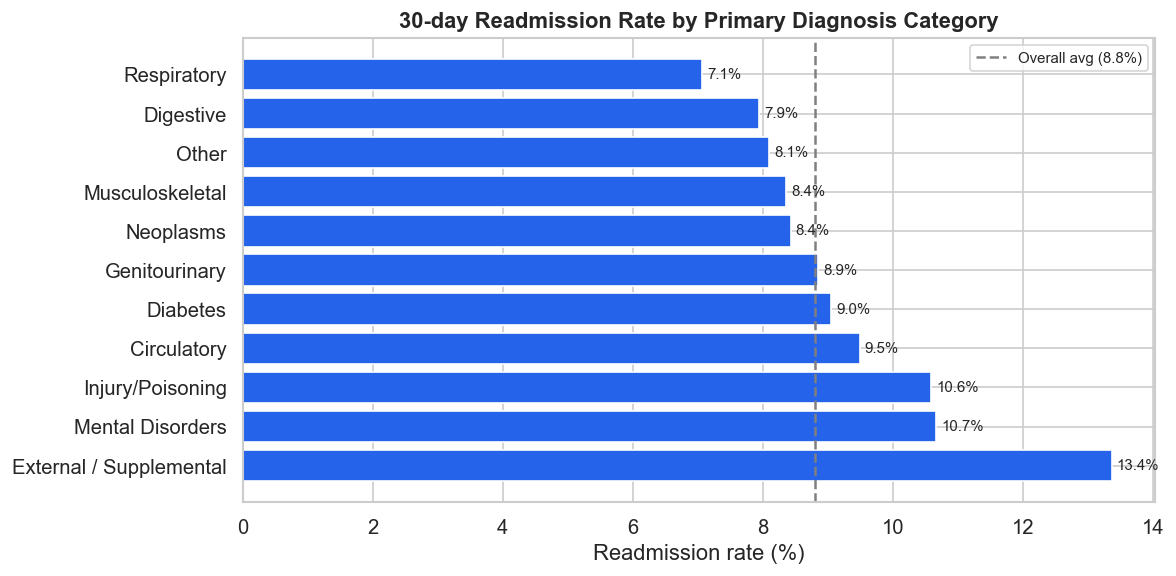

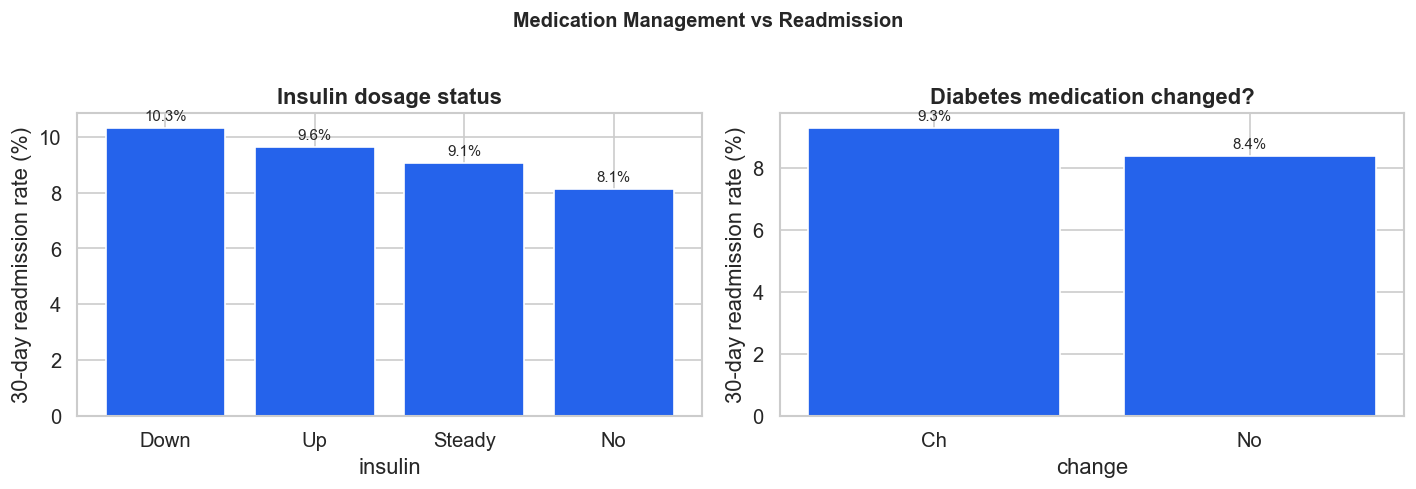

💡 Insight: Patients whose insulin was changed had a notably different readmission rate.
   Medication change is a strong candidate feature.


In [7]:
## 6. Clinical Feature Analysis
# ── Prior Hospital Visits vs Readmission ──────────────────────────────────────
# number_inpatient: # of inpatient visits in the year prior
# number_outpatient: # of outpatient visits in the year prior
# number_emergency: # of emergency visits in the year prior

visit_cols = ['number_inpatient', 'number_outpatient', 'number_emergency']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, visit_cols):
    readmit_yes = df[df['readmit_30'] == 1][col]
    readmit_no  = df[df['readmit_30'] == 0][col]
    ax.hist(readmit_no.clip(upper=10),  bins=11, alpha=0.6,
            color=PALETTE['success'], label='Not readmitted', density=True)
    ax.hist(readmit_yes.clip(upper=10), bins=11, alpha=0.6,
            color=PALETTE['danger'],  label='Readmitted <30d', density=True)
    ax.set_title(col.replace('number_', '').replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('# visits (capped at 10)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Prior Year Visits vs 30-day Readmission', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_prior_visits.png', bbox_inches='tight')
plt.show()

# Print mean difference
for col in visit_cols:
    m0 = df[df['readmit_30'] == 0][col].mean()
    m1 = df[df['readmit_30'] == 1][col].mean()
    print(f'{col:25s}: Not readmitted = {m0:.2f} | Readmitted = {m1:.2f}')
# ── Length of Stay vs Readmission ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

los_data = [
    df[df['readmit_30'] == 0]['time_in_hospital'].clip(upper=14),
    df[df['readmit_30'] == 1]['time_in_hospital'].clip(upper=14)
]
bp = ax.boxplot(los_data, labels=['Not readmitted', 'Readmitted <30 days'],
                patch_artist=True, notch=True,
                medianprops={'color': 'white', 'linewidth': 2})
for patch, color in zip(bp['boxes'], [PALETTE['success'], PALETTE['danger']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Length of Stay (days) vs 30-day Readmission', fontweight='bold')
ax.set_ylabel('Days in hospital (capped at 14)')
plt.tight_layout()
plt.savefig('06_length_of_stay.png', bbox_inches='tight')
plt.show()

los_diff = df.groupby('readmit_30')['time_in_hospital'].mean()
print(f'Avg LOS — Not readmitted: {los_diff[0]:.1f} days | Readmitted: {los_diff[1]:.1f} days')
# ── Medication Count vs Readmission ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
    ['num_medications', 'num_lab_procedures'],
    ['# Medications prescribed', '# Lab procedures']):
    for label, color in [(0, PALETTE['success']), (1, PALETTE['danger'])]:
        subset = df[df['readmit_30'] == label][col]
        ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=25,
                alpha=0.6, color=color, density=True,
                label='Not readmitted' if label == 0 else 'Readmitted <30d')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Medications & Lab Procedures vs Readmission', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('07_medications_labs.png', bbox_inches='tight')
plt.show()
# ── Top Primary Diagnoses vs Readmission ──────────────────────────────────────
# diag_1: primary diagnosis (ICD-9 code)
# We'll map codes to broader categories for readability

def map_icd9(code):
    """Map ICD-9 codes to broad clinical categories."""
    try:
        code = str(code).upper()
        if code.startswith('V') or code.startswith('E'):
            return 'External / Supplemental'
        c = float(code)
        if   390 <= c <= 459 or c == 785: return 'Circulatory'
        elif 460 <= c <= 519 or c == 786: return 'Respiratory'
        elif 520 <= c <= 579 or c == 787: return 'Digestive'
        elif 250 <= c <= 250.93:          return 'Diabetes'
        elif 800 <= c <= 999:             return 'Injury/Poisoning'
        elif 710 <= c <= 739:             return 'Musculoskeletal'
        elif 580 <= c <= 629 or c == 788: return 'Genitourinary'
        elif 140 <= c <= 239:             return 'Neoplasms'
        elif 290 <= c <= 319:             return 'Mental Disorders'
        else:                             return 'Other'
    except:
        return 'Unknown'

df['diag1_category'] = df['diag_1'].apply(map_icd9)

diag_readmit = (
    df.groupby('diag1_category')['readmit_30']
      .agg(['mean', 'count'])
      .query('count >= 100')
      .sort_values('mean', ascending=False)
      .reset_index()
)
diag_readmit['mean_pct'] = diag_readmit['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(diag_readmit['diag1_category'], diag_readmit['mean_pct'],
               color=PALETTE['primary'], edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
ax.axvline(df['readmit_30'].mean() * 100, ls='--', color='gray',
           label=f'Overall avg ({df["readmit_30"].mean()*100:.1f}%)')
ax.set_title('30-day Readmission Rate by Primary Diagnosis Category', fontweight='bold')
ax.set_xlabel('Readmission rate (%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('08_diagnosis_readmission.png', bbox_inches='tight')
plt.show()
# ── Insulin & Medication Changes ──────────────────────────────────────────────
# insulin: dosage change (Up, Down, Steady, No)
# change: whether any diabetic medication changed (Ch, No)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes, ['insulin', 'change'],
                          ['Insulin dosage status', 'Diabetes medication changed?']):
    grp = (
        df.groupby(col)['readmit_30'].mean() * 100
    ).sort_values(ascending=False)
    bars = ax.bar(grp.index, grp.values, color=PALETTE['primary'], edgecolor='white')
    ax.bar_label(bars, fmt='{:.1f}%', padding=3, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('30-day readmission rate (%)')
    ax.set_xlabel(col)

plt.suptitle('Medication Management vs Readmission', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('09_medication_management.png', bbox_inches='tight')
plt.show()

print('💡 Insight: Patients whose insulin was changed had a notably different readmission rate.')
print('   Medication change is a strong candidate feature.')


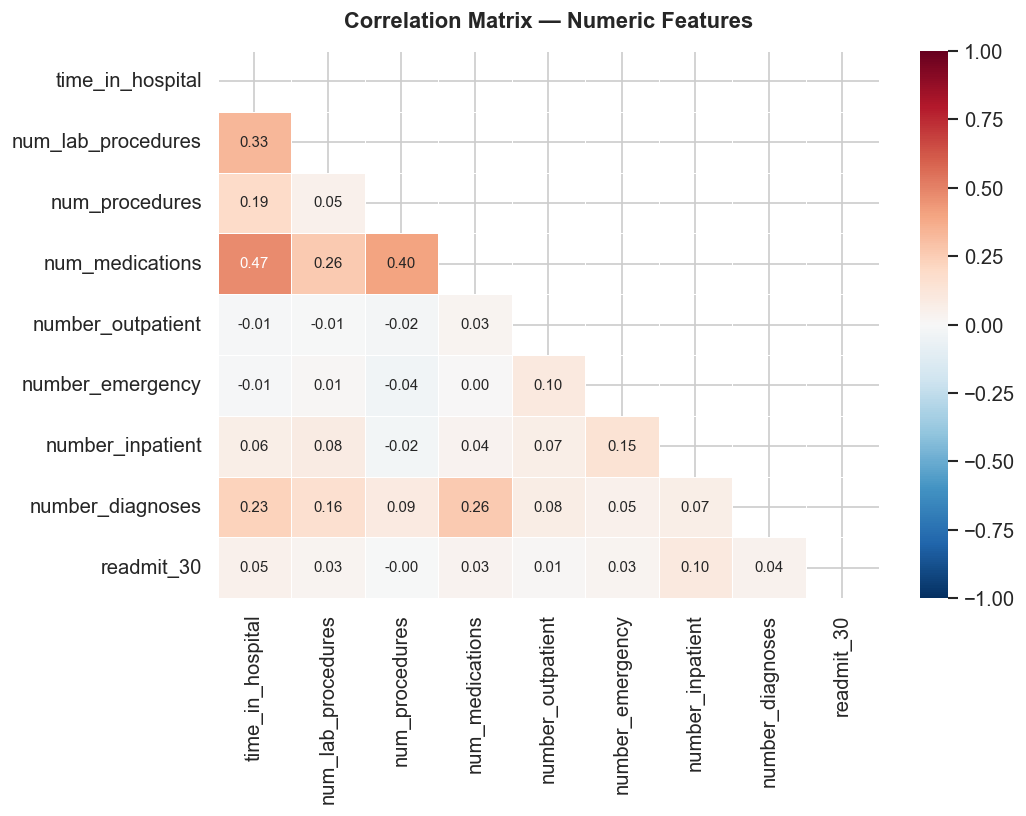

Top correlations with readmit_30:
number_inpatient     0.10
time_in_hospital     0.05
number_diagnoses     0.04
num_medications      0.03
num_lab_procedures   0.03
number_emergency     0.03
number_outpatient    0.01
num_procedures       0.00


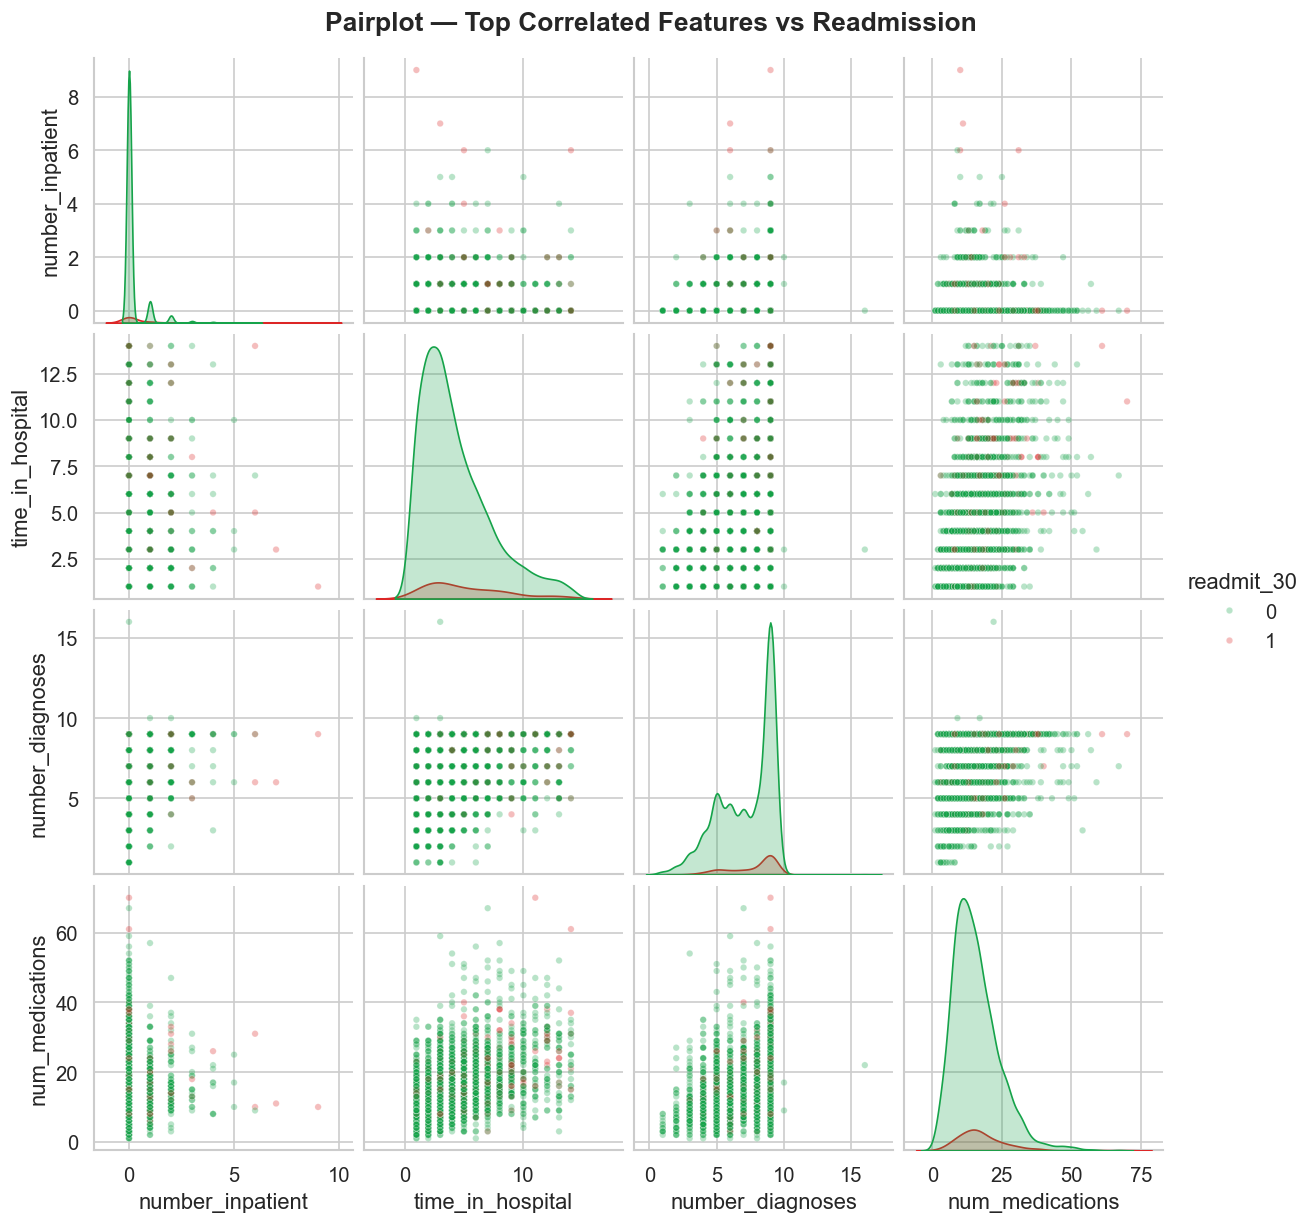

In [8]:
## 7. Correlation & Multivariate Analysis
# ── Correlation Heatmap (Numeric Features) ────────────────────────────────────
numeric_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'readmit_30'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr['readmit_30'].drop('readmit_30').abs().sort_values(ascending=False)
print('Top correlations with readmit_30:')
print(target_corr.to_string())
# ── Pairplot (Top 4 Numeric Features) ─────────────────────────────────────────
top_features = target_corr.head(4).index.tolist() + ['readmit_30']

sample = df[top_features].sample(n=min(3000, len(df)), random_state=42)

g = sns.pairplot(
    sample, hue='readmit_30', diag_kind='kde',
    palette={0: PALETTE['success'], 1: PALETTE['danger']},
    plot_kws={'alpha': 0.3, 's': 15}
)
g.fig.suptitle('Pairplot — Top Correlated Features vs Readmission', y=1.02, fontweight='bold')
plt.savefig('11_pairplot.png', bbox_inches='tight')
plt.show()


In [9]:
## 8. Key Insights Summary

#Run the cell below to generate a structured summary of findings to include in your README.
# ── EDA Summary ───────────────────────────────────────────────────────────────
import os
os.makedirs('plots', exist_ok=True)

readmit_rate    = df['readmit_30'].mean() * 100
total_patients  = len(df)
missing_cols    = df.isnull().sum()
high_missing    = missing_cols[missing_cols / len(df) > 0.4].index.tolist()
top_corr_feat   = target_corr.idxmax()

summary = f"""
╔══════════════════════════════════════════════════════════╗
║          PHASE 1 EDA — KEY FINDINGS                     ║
╠══════════════════════════════════════════════════════════╣
║ Dataset                                                  ║
║   Total patients (1 encounter each): {total_patients:,}           ║
║   Features: 50 columns                                  ║
╠══════════════════════════════════════════════════════════╣
║ Target                                                   ║
║   30-day readmission rate: {readmit_rate:.1f}%                   ║
║   → Imbalanced dataset; SMOTE needed in Phase 2         ║
╠══════════════════════════════════════════════════════════╣
║ Missing Data                                             ║
║   High-missing cols to drop: {high_missing}  ║
╠══════════════════════════════════════════════════════════╣
║ Top Predictors (from correlation)                        ║
║   Strongest numeric: {top_corr_feat}                        ║
║   Clinical flags: insulin change, # inpatient visits    ║
╠══════════════════════════════════════════════════════════╣
║ Next Steps (Phase 2)                                     ║
║   1. Drop high-missing columns                           ║
║   2. Encode ICD-9 codes → diagnosis categories          ║
║   3. Engineer: total_visits, comorbidity_score          ║
║   4. Apply SMOTE to balance classes                     ║
║   5. Train-test split (80/20, stratified)               ║
╚══════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════╗
║          PHASE 1 EDA — KEY FINDINGS                     ║
╠══════════════════════════════════════════════════════════╣
║ Dataset                                                  ║
║   Total patients (1 encounter each): 71,518           ║
║   Features: 50 columns                                  ║
╠══════════════════════════════════════════════════════════╣
║ Target                                                   ║
║   30-day readmission rate: 8.8%                   ║
║   → Imbalanced dataset; SMOTE needed in Phase 2         ║
╠══════════════════════════════════════════════════════════╣
║ Missing Data                                             ║
║   High-missing cols to drop: ['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']  ║
╠══════════════════════════════════════════════════════════╣
║ Top Predictors (from correlation)                        ║
║   Strongest numeric: number_inpatient         

In [10]:
df.to_csv("diabetes_cleaned.csv", index=False)

print("✅ Cleaned dataset saved successfully")

✅ Cleaned dataset saved successfully
